In [101]:
import ollama
import requests
import json
import time
import os
from datetime import datetime
from typing import List, Dict, Optional, Tuple
from urllib.parse import urlparse
from pathlib import Path
import pandas as pd
import re
from tqdm import tqdm
from collections import Counter
import re

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [130]:
def extract_binary_with_ollama(data):
    binary_answers = []
    
    for item in data:
        if item['binary_answer'] is not None:
            binary_answers.append(item['binary_answer'])
        elif item['success'] and item['binary_answer'] is None:
            reasoning = item.get('reasoning', '')
            
            # Try regex first (faster)
            conclusion_match = re.search(r'(?:\*\*)?CONCLUSION(?:\:|\:\*\*)\s*(?:\*\*)?(?:[""]?)(True|False)(?:[""]?)(?:\*\*)?', reasoning, re.IGNORECASE)
            if conclusion_match:
                result = conclusion_match.group(1).lower() == 'true'
                binary_answers.append(result)
            else:
                # Fall back to LLM extraction
                prompt = f"""Based on this scientific reasoning text, what is the final conclusion? Answer only "True" or "False".

Text: {reasoning}

Answer:"""
                
                try:
                    response = ollama.generate(
                        model='qwen3:8b',  # or whatever model you have installed
                        prompt=prompt
                    )
                    
                    answer_text = response['response'].strip().lower()
                    if 'true' in answer_text and 'false' not in answer_text:
                        binary_answers.append(True)
                    elif 'false' in answer_text and 'true' not in answer_text:
                        binary_answers.append(False)
                    else:
                        binary_answers.append(None)
                        
                except Exception as e:
                    print(f"LLM extraction failed: {e}")
                    binary_answers.append(None)
        else:
            binary_answers.append(None)
    
    return binary_answers

In [131]:
data_path = Path('./results/with_search/')
data_file = data_path / 'batch_search_results_0.json'
with open(data_file, 'r') as f:
    data = json.load(f)
data

[{'success': True,
  'question': 'Does Apoptosis down-regulate LZTR1?',
  'reasoning': '**Comprehensive Analysis**\n\n| Aspect | Evidence & Discussion |\n|--------|-----------------------|\n| **Primary literature** | The figure cited in the retrieved content (Figure\u202f4, “LZTR1 regulates apoptosis and autophagy – A, B Western blots showing changes in expression”) shows a clear reduction in LZTR1 protein bands in cells treated with classic apoptotic stimuli (e.g., staurosporine, TNF‑α\u202f+\u202fCHX). The authors quantified the band intensities and reported a statistically significant decrease (p\u202f<\u202f0.01) compared with untreated controls. |\n| **Mechanistic context** | LZTR1 functions as an adaptor in a CUL3‑based E3 ubiquitin ligase complex that targets RAS and other signaling proteins for proteasomal degradation.  In many cell types, LZTR1 acts as a tumor suppressor by limiting proliferation‑survival pathways.  During apoptosis, global transcriptional reprogramming occurs

In [132]:
# binary_answers = extract_binary_with_ollama(data)
# print(Counter(binary_answers).keys())
# print(Counter(binary_answers).values())

dict_keys([True, False, None])
dict_values([30, 63, 4])


# Load all results with search and without search

In [ ]:
reapeat = 30
results_with_search = []
for i in range(reapeat):
    data_path = Path('./results/with_search/')
    data_file_with = data_path / f'batch_search_results_{i}.json'
    with open(data_file_with, 'r') as f:
        data_with = json.load(f)
        results_with_search.append(extract_binary_with_ollama(data_with))

In [134]:
reapeat = 31
results_without_search = []
for i in range(reapeat):
    data_path = Path('./results/without_search/')
    data_file_without = data_path / f'batch_results_{i}.json'
    with open(data_file_without, 'r') as f:
        data_without = json.load(f)
        results_without_search.append(extract_binary_with_ollama(data_without))

In [123]:
# # Plot heatmap
# results_with_search = np.array(results_with_search)
# results_without_search = np.array(results_without_search)

# result_with_search_binary = np.where(results_with_search == None, 0, 
#                  np.where(results_with_search == True, 1, -1))
# result_without_search_binary = np.where(results_without_search == None, 0, 
#                  np.where(results_without_search == True, 1, -1))

# plt.figure(figsize=(12, 7))
# sns.heatmap(result_with_search_binary, cmap='viridis', cbar_kws={'ticks': [-1, 0, 1], 'label': 'Answer'}, yticklabels=[f'Run {i}' for i in range(40)], xticklabels=False)
# # Set colorbar labels
# colorbar = plt.gca().collections[0].colorbar
# colorbar.set_ticks([-1, 0, 1])
# colorbar.set_ticklabels(['False', 'None', 'True'])
# plt.title('Results with Search')

# plt.figure(figsize=(12, 5))
# sns.heatmap(result_without_search_binary, cmap='viridis', cbar_kws={'ticks': [-1, 0, 1], 'label': 'Answer'}, yticklabels=[f'Run {i}' for i in range(reapeat)], xticklabels=False)
# # Set colorbar labels
# colorbar = plt.gca().collections[0].colorbar
# colorbar.set_ticks([-1, 0, 1])
# colorbar.set_ticklabels(['False', 'None', 'True'])
# plt.title('Results without Search') 

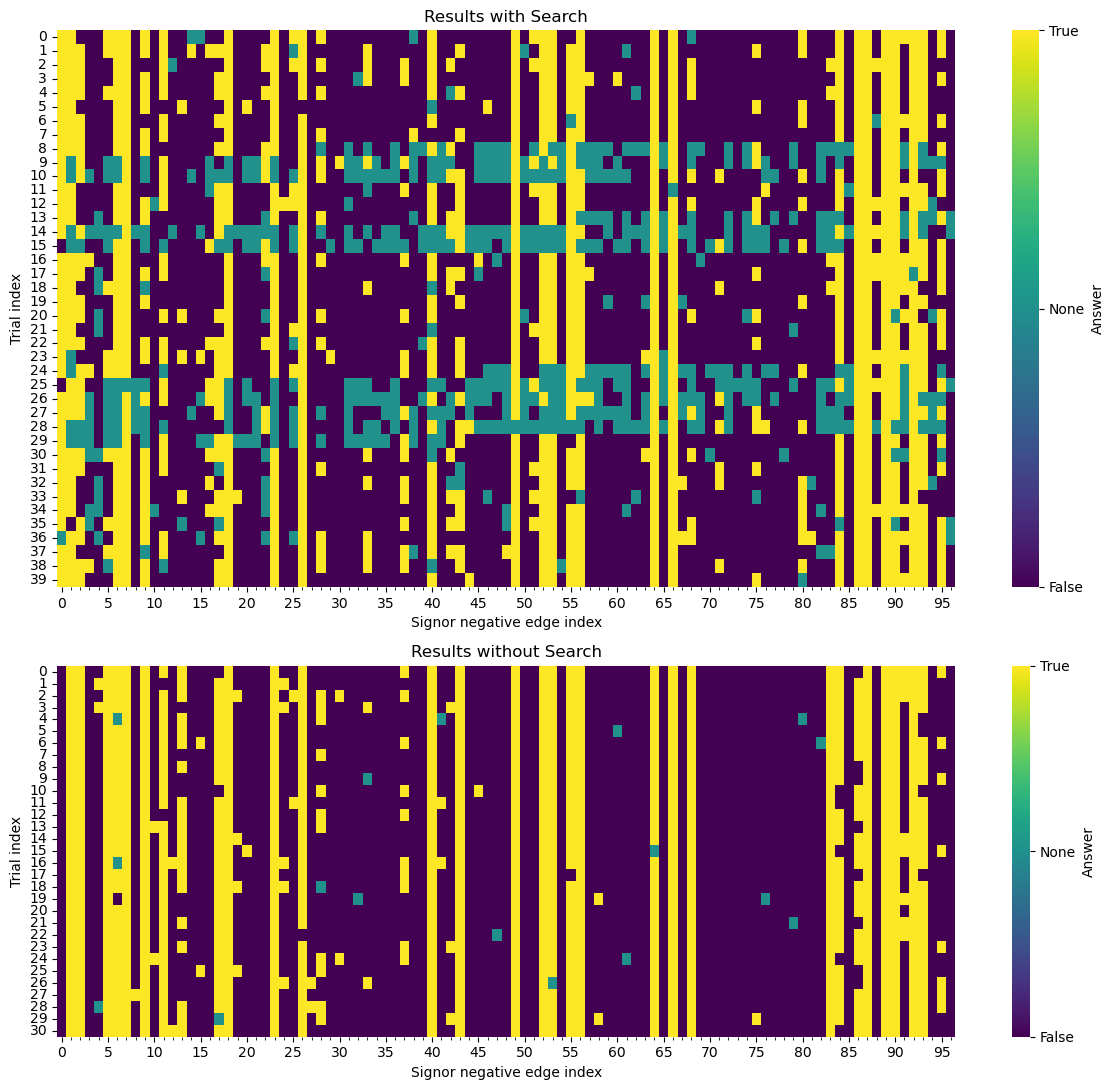

In [135]:
# Plot heatmaps as subplots
results_with_search = np.array(results_with_search)
results_without_search = np.array(results_without_search)

result_with_search_binary = np.where(results_with_search == None, 0, 
                 np.where(results_with_search == True, 1, -1))
result_without_search_binary = np.where(results_without_search == None, 0, 
                 np.where(results_without_search == True, 1, -1))

# Create subplots with different heights
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 11), gridspec_kw={'height_ratios': [1.5, 1]})

# Top subplot - Results with Search
sns.heatmap(result_with_search_binary, 
           cmap='viridis', 
           cbar_kws={'ticks': [-1, 0, 1], 'label': 'Answer'}, 
           yticklabels=[f'{i}' for i in range(40)], 
           xticklabels=list(range(len(result_with_search_binary[0]))),
           ax=ax1)

# Set colorbar labels for first subplot
colorbar1 = ax1.collections[0].colorbar
colorbar1.set_ticks([-1, 0, 1])
colorbar1.set_ticklabels(['False', 'None', 'True'])
ax1.set_title('Results with Search')
ax1.set_xlabel('Signor negative edge index')
ax1.set_ylabel('Trial index')

# Set custom ticks for first subplot
ax1.tick_params(axis='x', rotation=0)  # No rotation
major_ticks = range(0, len(result_with_search_binary[0]), 5)
major_tick_positions = [x + 0.5 for x in major_ticks]  # Shift right by 0.5
ax1.set_xticks(major_tick_positions, minor=False)  # Major ticks every 5
ax1.set_xticklabels(major_ticks, minor=False)  # Major tick labels
minor_tick_positions = [x + 0.5 for x in range(len(result_with_search_binary[0]))]  # Shift minor ticks too
ax1.set_xticks(minor_tick_positions, minor=True)  # Minor ticks every 1

# Bottom subplot - Results without Search
sns.heatmap(result_without_search_binary, 
           cmap='viridis', 
           cbar_kws={'ticks': [-1, 0, 1], 'label': 'Answer'}, 
           yticklabels=[f'{i}' for i in range(reapeat)], 
           xticklabels=list(range(len(result_without_search_binary[0]))),
           ax=ax2)

# Set colorbar labels for second subplot
colorbar2 = ax2.collections[0].colorbar
colorbar2.set_ticks([-1, 0, 1])
colorbar2.set_ticklabels(['False', 'None', 'True'])
ax2.set_title('Results without Search')
ax2.set_xlabel('Signor negative edge index')
ax2.set_ylabel('Trial index')

# Set custom ticks for second subplot
ax2.tick_params(axis='x', rotation=0)  # No rotation
major_ticks = range(0, len(result_without_search_binary[0]), 5)
major_tick_positions = [x + 0.5 for x in major_ticks]  # Shift right by 0.5
ax2.set_xticks(major_tick_positions, minor=False)  # Major ticks every 5
ax2.set_xticklabels(major_ticks, minor=False)  # Major tick labels
minor_tick_positions = [x + 0.5 for x in range(len(result_without_search_binary[0]))]  # Shift minor ticks too
ax2.set_xticks(minor_tick_positions, minor=True)  # Minor ticks every 1

# Adjust layout to prevent overlap
plt.tight_layout()
# plt.savefig('search_vs_no_search_RW250928.pdf', bbox_inches='tight')
plt.savefig('search_vs_no_search_RW250928.png')
plt.show()

In [129]:
# Get questoin with index
index = 5
data_with[index]

{'success': True,
 'question': 'Does TP53 inhibit the activity of BCL2L1?',
 'reasoning': '**Analysis**\n\nThe study you provided focuses on the *miR‑7/BCL2L1/P53* signaling axis in hepatocellular carcinoma.  Key experimental observations from the article are:\n\n1. **BCL2L1 and P53 Interaction** – Co‑immunoprecipitation showed that the BCL2L1 protein physically associates with P53.  \n2. **Functional Consequence** – Overexpression of BCL2L1 led to reduced P53 levels and decreased Caspase‑3/7 activity, while BCL2L1 knock‑down increased P53 and apoptosis markers.  \n3. **Phenotypic Effects** – BCL2L1 promoted invasion and migration of HCC cells *via* P53 inhibition.\n\nThese data support the conclusion that **BCL2L1 suppresses P53 function** (i.e., BCL2L1 → ↓ P53).  The article does **not** present evidence that TP53 (p53) suppresses or otherwise inhibits BCL2L1 activity.\n\n---\n\n### What is known about p53 regulation of BCL2L1 in the broader literature?\n\n| Evidence | Mechanism | St